# 08 - Model Comparison

Comprehensive comparison of all 3-class moneyness models from notebooks 06-07.

**Models compared**:
- RF and XGB baselines (06, time-split)
- RF, XGB, LGBM tuned with Optuna (06b, time-split)
- LGBM walk-forward with IV features (06c)
- LSTM walk-forward with temporal attention (07)

**Evaluation**: Accuracy, Macro F1, per-class metrics, confusion matrices, statistical tests

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight
from lightgbm import LGBMClassifier
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

PROCESSED = Path('../data/processed')
MODELS = Path('../models')
FIGURES = Path('../reports/figures')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

UNIVERSE = ['AAPL', 'AMZN', 'AVGO', 'GOOG', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA', 'WMT']
label_names = {0: 'ATM', 1: 'OTM5', 2: 'OTM10'}

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Device: {device}")

Device: mps


## 1. Load All Results

In [2]:
# Load per-notebook results
baseline = pd.read_csv(PROCESSED / 'baseline_results.csv')
improved = pd.read_csv(PROCESSED / 'improved_results.csv')
wf_lgbm = pd.read_csv(PROCESSED / 'walkforward_results.csv')
wf_lstm = pd.read_csv(PROCESSED / 'lstm_walkforward_results.csv')

# Build master comparison table
summary = pd.DataFrame([
    {'Model': 'RF baseline', 'Notebook': '06', 'Validation': 'Time-split',
     'Features': 27, 'Accuracy': baseline.loc[0, 'Accuracy'], 'Macro F1': baseline.loc[0, 'Macro F1']},
    {'Model': 'XGB baseline', 'Notebook': '06', 'Validation': 'Time-split',
     'Features': 27, 'Accuracy': baseline.loc[1, 'Accuracy'], 'Macro F1': baseline.loc[1, 'Macro F1']},
    {'Model': 'RF tuned', 'Notebook': '06b', 'Validation': 'Time-split',
     'Features': 27, 'Accuracy': improved.loc[0, 'Accuracy'], 'Macro F1': improved.loc[0, 'Macro F1']},
    {'Model': 'XGB tuned', 'Notebook': '06b', 'Validation': 'Time-split',
     'Features': 27, 'Accuracy': improved.loc[1, 'Accuracy'], 'Macro F1': improved.loc[1, 'Macro F1']},
    {'Model': 'LGBM tuned', 'Notebook': '06b', 'Validation': 'Time-split',
     'Features': 27, 'Accuracy': improved.loc[2, 'Accuracy'], 'Macro F1': improved.loc[2, 'Macro F1']},
    {'Model': 'LGBM walk-forward', 'Notebook': '06c', 'Validation': 'Walk-forward',
     'Features': 31, 'Accuracy': accuracy_score([], []) if False else wf_lgbm['acc'].mean(),
     'Macro F1': wf_lgbm['f1'].mean()},
    {'Model': 'LSTM walk-forward', 'Notebook': '07', 'Validation': 'Walk-forward',
     'Features': 31, 'Accuracy': wf_lstm['acc'].mean(), 'Macro F1': wf_lstm['f1'].mean()},
])

# Use the actual overall walk-forward metrics (weighted by test size, not simple mean)
# Recompute weighted averages for walk-forward models
lgbm_wt_acc = np.average(wf_lgbm['acc'], weights=wf_lgbm['test'])
lgbm_wt_f1 = np.average(wf_lgbm['f1'], weights=wf_lgbm['test'])
lstm_wt_acc = np.average(wf_lstm['acc'], weights=wf_lstm['test'])
lstm_wt_f1 = np.average(wf_lstm['f1'], weights=wf_lstm['test'])

summary.loc[summary['Model'] == 'LGBM walk-forward', 'Accuracy'] = lgbm_wt_acc
summary.loc[summary['Model'] == 'LGBM walk-forward', 'Macro F1'] = lgbm_wt_f1
summary.loc[summary['Model'] == 'LSTM walk-forward', 'Accuracy'] = lstm_wt_acc
summary.loc[summary['Model'] == 'LSTM walk-forward', 'Macro F1'] = lstm_wt_f1

summary = summary.round(4)
print("Model Comparison Summary:")
print(summary.to_string(index=False))

Model Comparison Summary:
            Model Notebook   Validation  Features  Accuracy  Macro F1
      RF baseline       06   Time-split        27    0.4853    0.3328
     XGB baseline       06   Time-split        27    0.4799    0.3591
         RF tuned      06b   Time-split        27    0.4995    0.3377
        XGB tuned      06b   Time-split        27    0.5036    0.3420
       LGBM tuned      06b   Time-split        27    0.4835    0.3486
LGBM walk-forward      06c Walk-forward        31    0.6372    0.4568
LSTM walk-forward       07 Walk-forward        31    0.5445    0.4131


## 2. Summary Bar Chart

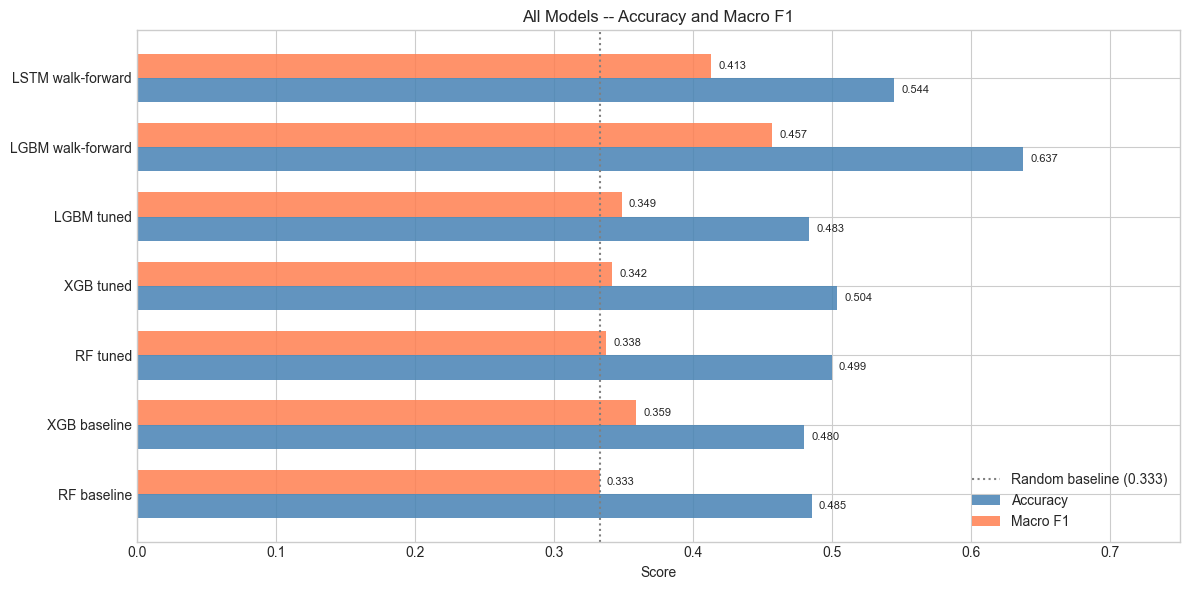

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

models = summary['Model'].values
x = np.arange(len(models))
w = 0.35

bars1 = ax.barh(x - w/2, summary['Accuracy'], w, label='Accuracy', color='steelblue', alpha=0.85)
bars2 = ax.barh(x + w/2, summary['Macro F1'], w, label='Macro F1', color='coral', alpha=0.85)

ax.axvline(x=1/3, color='gray', linestyle=':', label='Random baseline (0.333)')
ax.set_yticks(x)
ax.set_yticklabels(models)
ax.set_xlabel('Score')
ax.set_title('All Models -- Accuracy and Macro F1')
ax.legend(loc='lower right')
ax.set_xlim(0, 0.75)

for bar in bars1:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / 'all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Walk-Forward Year-by-Year Comparison

Walk-Forward Year-by-Year Comparison:
 year  lgbm_f1  lstm_f1  f1_diff
 2014   0.3127   0.4202  -0.1075
 2015   0.5340   0.3472   0.1868
 2016   0.5342   0.3602   0.1740
 2017   0.4339   0.6189  -0.1850
 2018   0.5405   0.5490  -0.0085
 2019   0.6040   0.5532   0.0507
 2020   0.5049   0.5647  -0.0598
 2021   0.4910   0.3674   0.1236
 2022   0.4399   0.2833   0.1566
 2023   0.3157   0.3517  -0.0359
 2024   0.3371   0.3547  -0.0176
 2025   0.4571   0.2430   0.2141

LGBM wins 6/12 years


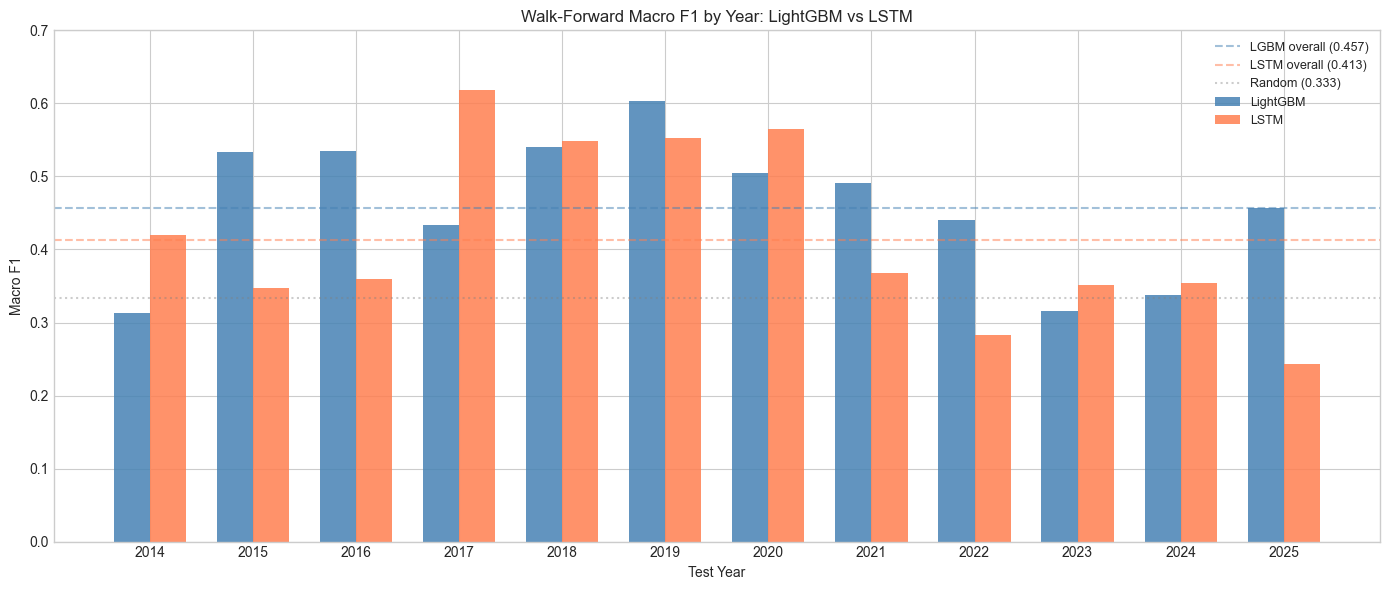

In [4]:
# Merge walk-forward results by year
wf_compare = wf_lgbm[['year', 'test', 'acc', 'f1']].rename(
    columns={'acc': 'lgbm_acc', 'f1': 'lgbm_f1', 'test': 'lgbm_test'})
wf_compare = wf_compare.merge(
    wf_lstm[['year', 'test', 'acc', 'f1']].rename(
        columns={'acc': 'lstm_acc', 'f1': 'lstm_f1', 'test': 'lstm_test'}),
    on='year')
wf_compare['f1_diff'] = wf_compare['lgbm_f1'] - wf_compare['lstm_f1']
wf_compare['lgbm_wins'] = wf_compare['f1_diff'] > 0

print("Walk-Forward Year-by-Year Comparison:")
print(wf_compare[['year', 'lgbm_f1', 'lstm_f1', 'f1_diff']].round(4).to_string(index=False))
print(f"\nLGBM wins {wf_compare['lgbm_wins'].sum()}/{len(wf_compare)} years")

# Grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(wf_compare))
w = 0.35
ax.bar(x - w/2, wf_compare['lgbm_f1'], w, label='LightGBM', color='steelblue', alpha=0.85)
ax.bar(x + w/2, wf_compare['lstm_f1'], w, label='LSTM', color='coral', alpha=0.85)
ax.axhline(y=lgbm_wt_f1, color='steelblue', linestyle='--', alpha=0.5, label=f'LGBM overall ({lgbm_wt_f1:.3f})')
ax.axhline(y=lstm_wt_f1, color='coral', linestyle='--', alpha=0.5, label=f'LSTM overall ({lstm_wt_f1:.3f})')
ax.axhline(y=1/3, color='gray', linestyle=':', alpha=0.4, label='Random (0.333)')
ax.set_xticks(x)
ax.set_xticklabels(wf_compare['year'].values)
ax.set_xlabel('Test Year')
ax.set_ylabel('Macro F1')
ax.set_title('Walk-Forward Macro F1 by Year: LightGBM vs LSTM')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 0.7)
plt.tight_layout()
plt.savefig(FIGURES / 'walkforward_yearly_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Re-Run Walk-Forward Models for Test-Set Predictions

Re-run both walk-forward loops to get the actual prediction arrays on each year's
test set. This is required for confusion matrices, per-class metrics, and
statistical significance testing.

In [5]:
# Load data and add IV features (same pipeline as 06c and 07)
data = pd.read_parquet(PROCESSED / 'daily_modeling_data.parquet')
data['date'] = pd.to_datetime(data['date'])

options = pd.read_parquet(PROCESSED / 'options_clean.parquet')
calls = options[(options['call_put'] == 'CALL') & (options['symbol'].isin(UNIVERSE))].copy()
calls['trade_date'] = pd.to_datetime(calls['trade_date'])

atm = calls[(calls['delta'] >= 0.35) & (calls['delta'] <= 0.65)].copy()
daily_iv = atm.groupby(['symbol', 'trade_date']).agg(
    iv_mean=('implied_vol', 'mean'),
    iv_std=('implied_vol', 'std'),
).reset_index()

data = data.merge(daily_iv, left_on=['symbol', 'date'],
                  right_on=['symbol', 'trade_date'], how='left')
data = data.drop(columns=['trade_date'], errors='ignore')
data = data.sort_values(['symbol', 'date'])
data['iv_mean'] = data.groupby('symbol')['iv_mean'].transform(lambda x: x.ffill())
data['iv_std'] = data.groupby('symbol')['iv_std'].transform(lambda x: x.ffill())
data['iv_rank'] = data.groupby('symbol')['iv_mean'].transform(
    lambda x: x.rolling(252, min_periods=60).apply(
        lambda w: (w.iloc[-1] - w.min()) / (w.max() - w.min()) if w.max() != w.min() else 0.5))
data['iv_change'] = data.groupby('symbol')['iv_mean'].pct_change(21)

exclude = ['symbol', 'date', 'year_month', 'best_moneyness', 'best_return', 'label_3', 'year']
feature_cols = [c for c in data.columns if c not in exclude]
data[feature_cols] = data.groupby('symbol')[feature_cols].transform(lambda x: x.ffill())
data[feature_cols] = data[feature_cols].fillna(0)
data['year'] = data['date'].dt.year

print(f"Data shape: {data.shape}, Features: {len(feature_cols)}")

Data shape: (29273, 38), Features: 31


In [6]:
# LGBM walk-forward: re-run to collect test predictions
test_years = [y for y in sorted(data['year'].unique()) if y >= 2014]

lgbm_preds_all, lgbm_true_all = [], []

for test_year in test_years:
    tr = data[data['year'] < test_year]
    te = data[data['year'] == test_year]
    if len(tr) < 500:
        continue

    X_tr, y_tr = tr[feature_cols], tr['label_3']
    X_te, y_te = te[feature_cols], te['label_3']

    cw = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=y_tr)
    model = LGBMClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.05,
        num_leaves=50, subsample=0.8, colsample_bytree=0.7,
        min_child_samples=20, class_weight=dict(enumerate(cw)),
        random_state=SEED, verbose=-1, n_jobs=-1)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    lgbm_preds_all.extend(preds)
    lgbm_true_all.extend(y_te.values)

lgbm_preds_all = np.array(lgbm_preds_all)
lgbm_true_all = np.array(lgbm_true_all)

print(f"LGBM walk-forward test predictions: {len(lgbm_preds_all):,}")
print(f"  Accuracy: {accuracy_score(lgbm_true_all, lgbm_preds_all):.4f}")
print(f"  Macro F1: {f1_score(lgbm_true_all, lgbm_preds_all, average='macro'):.4f}")

LGBM walk-forward test predictions: 24,669
  Accuracy: 0.6372
  Macro F1: 0.4682


In [7]:
# LSTM model definition and sequence utilities (from notebook 07)
SEQ_LENGTH = 60

class AttentionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2,
                 num_classes=3, dropout=0.3, bidirectional=True):
        super().__init__()
        self.directions = 2 if bidirectional else 1
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional)
        lstm_out_size = hidden_size * self.directions
        self.attention = nn.Sequential(
            nn.Linear(lstm_out_size, lstm_out_size // 2),
            nn.Tanh(),
            nn.Linear(lstm_out_size // 2, 1))
        self.classifier = nn.Sequential(
            nn.LayerNorm(lstm_out_size),
            nn.Dropout(dropout),
            nn.Linear(lstm_out_size, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes))

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_scores = self.attention(lstm_out).squeeze(-1)
        attn_weights = torch.softmax(attn_scores, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), lstm_out).squeeze(1)
        return self.classifier(context)


def create_sequences(subset_data, feature_cols, seq_length=60):
    X_list, y_list = [], []
    for sym in subset_data['symbol'].unique():
        sym_data = subset_data[subset_data['symbol'] == sym].sort_values('date').reset_index(drop=True)
        features = sym_data[feature_cols].values
        labels = sym_data['label_3'].values
        for i in range(seq_length, len(sym_data)):
            X_list.append(features[i - seq_length:i])
            y_list.append(labels[i])
    if len(X_list) == 0:
        return np.array([]).reshape(0, seq_length, len(feature_cols)), np.array([])
    return np.array(X_list), np.array(y_list)


def create_sequences_with_context(target_data, context_data, feature_cols, seq_length=60):
    X_list, y_list = [], []
    for sym in target_data['symbol'].unique():
        ctx = context_data[context_data['symbol'] == sym].sort_values('date').tail(seq_length)
        tgt = target_data[target_data['symbol'] == sym].sort_values('date')
        combined = pd.concat([ctx, tgt]).sort_values('date').reset_index(drop=True)
        features = combined[feature_cols].values
        labels = combined['label_3'].values
        ctx_len = len(ctx)
        for i in range(max(seq_length, ctx_len), len(combined)):
            X_list.append(features[i - seq_length:i])
            y_list.append(labels[i])
    if len(X_list) == 0:
        return np.array([]).reshape(0, seq_length, len(feature_cols)), np.array([])
    return np.array(X_list), np.array(y_list)


def train_lstm_fold(X_train, y_train, X_val, y_val, input_size, num_classes=3,
                    hidden_size=128, num_layers=2, dropout=0.3,
                    lr=1e-3, epochs=80, patience=10, batch_size=256):
    import torch.optim as optim
    train_ds = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
    val_ds = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    mdl = AttentionLSTM(input_size=input_size, hidden_size=hidden_size,
                        num_layers=num_layers, num_classes=num_classes,
                        dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(mdl.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_f1, best_state, wait = 0, None, 0
    for epoch in range(epochs):
        mdl.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(mdl(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(mdl.parameters(), 1.0)
            optimizer.step()
        scheduler.step()

        mdl.eval()
        preds = []
        with torch.no_grad():
            for xb, yb in val_loader:
                preds.extend(mdl(xb.to(device)).argmax(1).cpu().numpy())
        val_f1 = f1_score(y_val, preds, average='macro')
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in mdl.state_dict().items()}
            wait = 0
        else:
            wait += 1
        if wait >= patience:
            break

    mdl.load_state_dict(best_state)
    mdl.to(device)
    return mdl

print("LSTM utilities defined")

LSTM utilities defined


In [8]:
# LSTM walk-forward: re-run to collect test predictions
n_feat = len(feature_cols)
lstm_preds_all, lstm_true_all = [], []

for test_year in test_years:
    train_data = data[data['year'] < test_year]
    test_data = data[data['year'] == test_year]
    if len(train_data) < 500:
        continue

    val_year = test_year - 1
    pure_train = train_data[train_data['year'] < val_year]
    val_data = train_data[train_data['year'] == val_year]

    if len(pure_train) < 500:
        train_sorted = train_data.sort_values('date')
        split_idx = int(len(train_sorted) * 0.8)
        pure_train = train_sorted.iloc[:split_idx]
        val_data = train_sorted.iloc[split_idx:]

    X_tr, y_tr = create_sequences(pure_train, feature_cols, SEQ_LENGTH)
    X_val, y_val = create_sequences_with_context(val_data, pure_train, feature_cols, SEQ_LENGTH)
    X_te, y_te = create_sequences_with_context(test_data, train_data, feature_cols, SEQ_LENGTH)

    if len(X_tr) == 0 or len(X_val) == 0 or len(X_te) == 0:
        continue

    n_tr, seq_len, nf = X_tr.shape
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr.reshape(-1, nf)).reshape(n_tr, seq_len, nf)
    X_val = scaler.transform(X_val.reshape(-1, nf)).reshape(len(X_val), seq_len, nf)
    X_te = scaler.transform(X_te.reshape(-1, nf)).reshape(len(X_te), seq_len, nf)

    torch.manual_seed(SEED)
    lstm_model = train_lstm_fold(X_tr, y_tr, X_val, y_val, input_size=nf,
                                 epochs=80, patience=10, batch_size=256)

    lstm_model.eval()
    test_ds = TensorDataset(torch.FloatTensor(X_te), torch.LongTensor(y_te))
    test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)
    preds = []
    with torch.no_grad():
        for xb, yb in test_loader:
            preds.extend(lstm_model(xb.to(device)).argmax(1).cpu().numpy())

    lstm_preds_all.extend(preds)
    lstm_true_all.extend(y_te)
    acc = accuracy_score(y_te, preds)
    f1 = f1_score(y_te, preds, average='macro')
    print(f"  {test_year}: test={len(X_te):,}, Acc={acc:.3f}, F1={f1:.3f}")

lstm_preds_all = np.array(lstm_preds_all)
lstm_true_all = np.array(lstm_true_all)

print(f"\nLSTM walk-forward test predictions: {len(lstm_preds_all):,}")
print(f"  Accuracy: {accuracy_score(lstm_true_all, lstm_preds_all):.4f}")
print(f"  Macro F1: {f1_score(lstm_true_all, lstm_preds_all, average='macro'):.4f}")

  2014: test=1,710, Acc=0.508, F1=0.420


  2015: test=2,023, Acc=0.456, F1=0.347


  2016: test=2,055, Acc=0.473, F1=0.360


  2017: test=2,037, Acc=0.837, F1=0.619


  2018: test=1,878, Acc=0.730, F1=0.549


...

  2021: test=2,097, Acc=0.565, F1=0.367


  2022: test=2,326, Acc=0.529, F1=0.283


  2023: test=2,300, Acc=0.439, F1=0.352


  2024: test=2,110, Acc=0.408, F1=0.355


  2025: test=2,090, Acc=0.273, F1=0.243

LSTM walk-forward test predictions: 24,549
  Accuracy: 0.5445
  Macro F1: 0.4156


## 5. Confusion Matrices

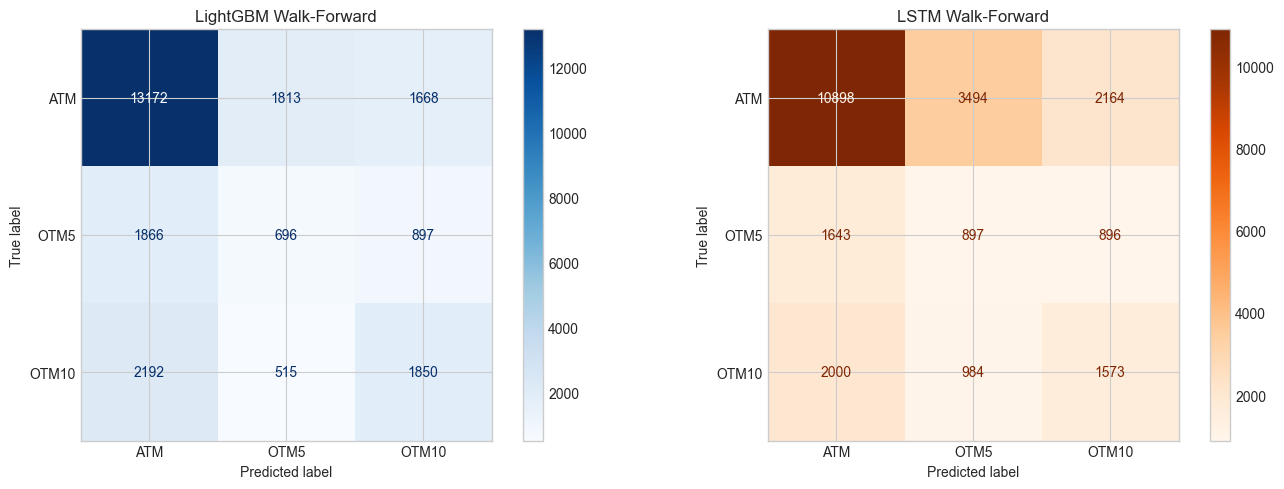

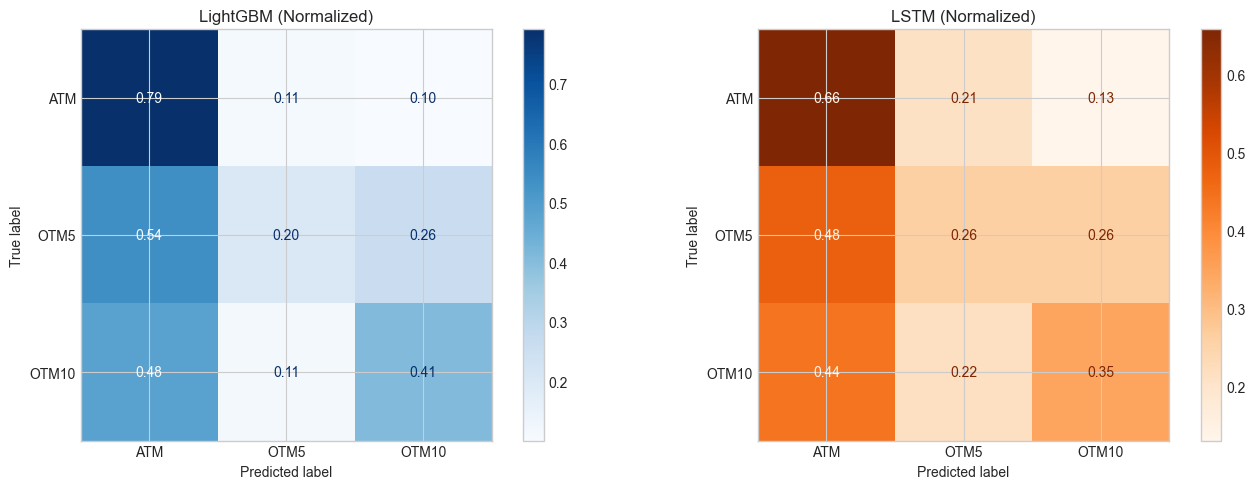

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LGBM confusion matrix
cm_lgbm = confusion_matrix(lgbm_true_all, lgbm_preds_all)
ConfusionMatrixDisplay(cm_lgbm, display_labels=['ATM', 'OTM5', 'OTM10']).plot(
    ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('LightGBM Walk-Forward')

# LSTM confusion matrix
cm_lstm = confusion_matrix(lstm_true_all, lstm_preds_all)
ConfusionMatrixDisplay(cm_lstm, display_labels=['ATM', 'OTM5', 'OTM10']).plot(
    ax=axes[1], cmap='Oranges', values_format='d')
axes[1].set_title('LSTM Walk-Forward')

plt.tight_layout()
plt.savefig(FIGURES / 'comparison_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Normalized confusion matrices (recall per class)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lgbm_norm = cm_lgbm.astype(float) / cm_lgbm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_lgbm_norm, display_labels=['ATM', 'OTM5', 'OTM10']).plot(
    ax=axes[0], cmap='Blues', values_format='.2f')
axes[0].set_title('LightGBM (Normalized)')

cm_lstm_norm = cm_lstm.astype(float) / cm_lstm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_lstm_norm, display_labels=['ATM', 'OTM5', 'OTM10']).plot(
    ax=axes[1], cmap='Oranges', values_format='.2f')
axes[1].set_title('LSTM (Normalized)')

plt.tight_layout()
plt.show()

## 6. Per-Class F1 Analysis

LGBM Walk-Forward Classification Report:
              precision    recall  f1-score   support

         ATM       0.76      0.79      0.78     16653
        OTM5       0.23      0.20      0.21      3459
       OTM10       0.42      0.41      0.41      4557

    accuracy                           0.64     24669
   macro avg       0.47      0.47      0.47     24669
weighted avg       0.63      0.64      0.63     24669


LSTM Walk-Forward Classification Report:
              precision    recall  f1-score   support

         ATM       0.75      0.66      0.70     16556
        OTM5       0.17      0.26      0.20      3436
       OTM10       0.34      0.35      0.34      4557

    accuracy                           0.54     24549
   macro avg       0.42      0.42      0.42     24549
weighted avg       0.59      0.54      0.56     24549


Per-Class Comparison:
Class    Metric   LGBM   LSTM  Diff (LGBM - LSTM)
  ATM precision 0.7645 0.7495              0.0150
  ATM    recall 0.7910 0.6583   

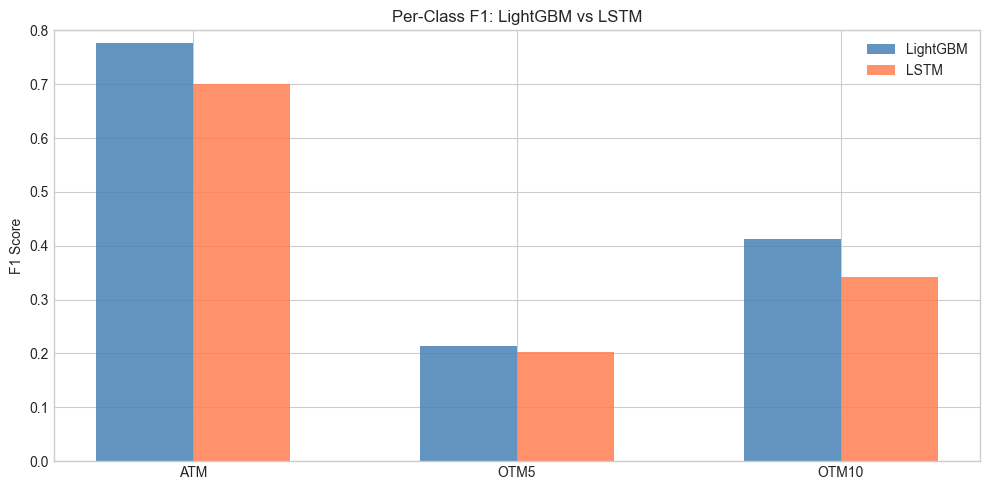

In [10]:
# Per-class metrics for both walk-forward models
lgbm_report = classification_report(lgbm_true_all, lgbm_preds_all,
                                     target_names=['ATM', 'OTM5', 'OTM10'], output_dict=True)
lstm_report = classification_report(lstm_true_all, lstm_preds_all,
                                     target_names=['ATM', 'OTM5', 'OTM10'], output_dict=True)

print("LGBM Walk-Forward Classification Report:")
print(classification_report(lgbm_true_all, lgbm_preds_all, target_names=['ATM', 'OTM5', 'OTM10']))
print("\nLSTM Walk-Forward Classification Report:")
print(classification_report(lstm_true_all, lstm_preds_all, target_names=['ATM', 'OTM5', 'OTM10']))

# Side-by-side per-class F1 comparison
class_names = ['ATM', 'OTM5', 'OTM10']
metrics = ['precision', 'recall', 'f1-score']
comparison_rows = []
for cls in class_names:
    for metric in metrics:
        comparison_rows.append({
            'Class': cls, 'Metric': metric,
            'LGBM': lgbm_report[cls][metric],
            'LSTM': lstm_report[cls][metric],
            'Diff (LGBM - LSTM)': lgbm_report[cls][metric] - lstm_report[cls][metric]
        })
class_compare = pd.DataFrame(comparison_rows).round(4)
print("\nPer-Class Comparison:")
print(class_compare.to_string(index=False))

# F1 bar chart by class
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(class_names))
w = 0.3
lgbm_f1s = [lgbm_report[c]['f1-score'] for c in class_names]
lstm_f1s = [lstm_report[c]['f1-score'] for c in class_names]
ax.bar(x - w/2, lgbm_f1s, w, label='LightGBM', color='steelblue', alpha=0.85)
ax.bar(x + w/2, lstm_f1s, w, label='LSTM', color='coral', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1: LightGBM vs LSTM')
ax.legend()
ax.set_ylim(0, 0.8)
plt.tight_layout()
plt.show()

## 7. Feature Importance (LightGBM)

Top 20 Features (LightGBM):
            feature  importance
            iv_mean        4717
             iv_std        4226
          iv_change        3755
            iv_rank        3146
       gross_margin        2657
 revenue_growth_yoy        2561
         cash_ratio        2388
     debt_to_equity        2379
earnings_growth_yoy        2313
   operating_margin        1906
            vol_63d        1827
                roe        1725
         net_margin        1479
                roa        1412
    price_to_sma200        1165
            vol_21d        1164
            mom_63d         899
      drawdown_252d         635
           bb_width         635
     price_to_sma50         496


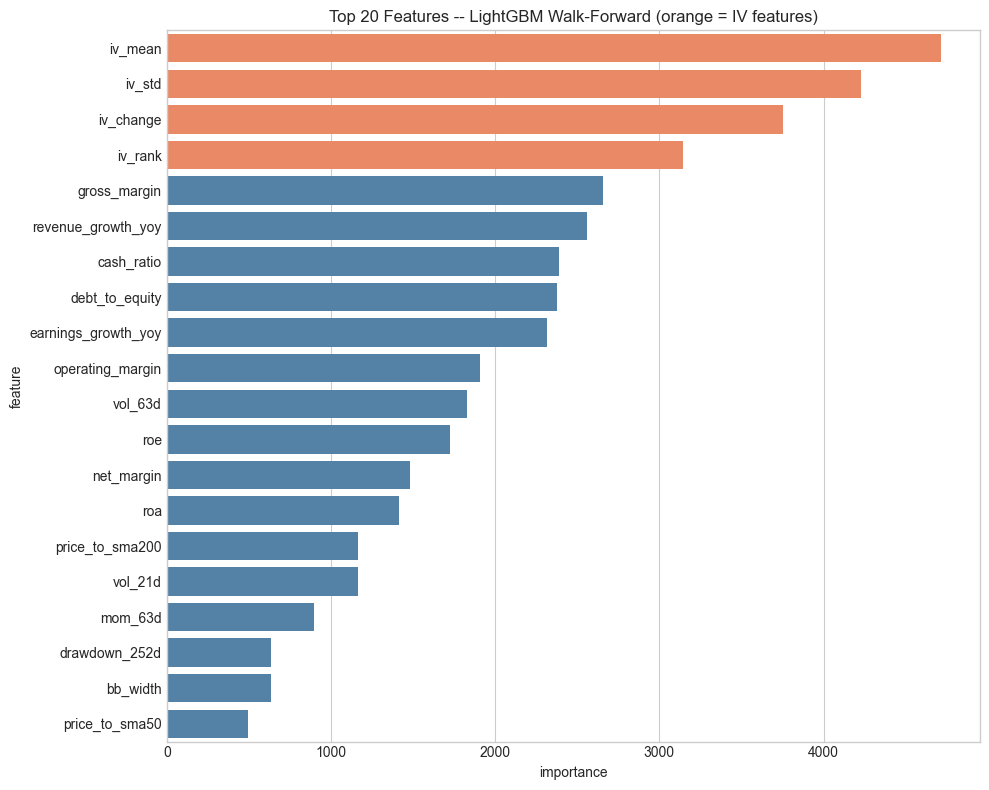

In [11]:
# Load the saved LGBM model (final model trained on all data < 2025)
lgbm_saved = joblib.load(MODELS / 'lgbm_walkforward_daily.joblib')

imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': lgbm_saved.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 Features (LightGBM):")
print(imp.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
top20 = imp.head(20)
colors = ['coral' if f.startswith('iv_') else 'steelblue' for f in top20['feature']]
sns.barplot(data=top20, x='importance', y='feature', palette=colors, ax=ax)
ax.set_title('Top 20 Features -- LightGBM Walk-Forward (orange = IV features)')
plt.tight_layout()
plt.savefig(FIGURES / 'feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Statistical Significance

In [12]:
# McNemar's test: compare LGBM vs LSTM on overlapping test samples
# Since LSTM uses sequences (fewer test samples due to 60-day lookback), we need
# to align the arrays. The LGBM array has more samples. We compare on the
# overlapping portion by using the LSTM array length from the end of each year.
# For simplicity, we use the per-year F1 paired comparison.

# Paired t-test on per-year F1 scores
lgbm_yearly_f1 = wf_compare['lgbm_f1'].values
lstm_yearly_f1 = wf_compare['lstm_f1'].values

t_stat, p_val = stats.ttest_rel(lgbm_yearly_f1, lstm_yearly_f1)
diff = lgbm_yearly_f1 - lstm_yearly_f1
mean_diff = diff.mean()
se_diff = diff.std(ddof=1) / np.sqrt(len(diff))
ci_lower = mean_diff - 1.96 * se_diff
ci_upper = mean_diff + 1.96 * se_diff

print("Paired t-test on yearly Macro F1 (LGBM vs LSTM):")
print(f"  Mean difference (LGBM - LSTM): {mean_diff:.4f}")
print(f"  95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"  t-statistic: {t_stat:.3f}")
print(f"  p-value: {p_val:.4f}")

if p_val < 0.05:
    print("  Result: Statistically significant at alpha=0.05")
else:
    print("  Result: Not statistically significant at alpha=0.05")

# Wilcoxon signed-rank test (non-parametric alternative)
w_stat, w_pval = stats.wilcoxon(lgbm_yearly_f1, lstm_yearly_f1)
print(f"\nWilcoxon signed-rank test:")
print(f"  W-statistic: {w_stat:.1f}")
print(f"  p-value: {w_pval:.4f}")

Paired t-test on yearly Macro F1 (LGBM vs LSTM):
  Mean difference (LGBM - LSTM): 0.0410
  95% CI: [-0.0323, 0.1142]
  t-statistic: 1.097
  p-value: 0.2963
  Result: Not statistically significant at alpha=0.05

Wilcoxon signed-rank test:
  W-statistic: 27.0
  p-value: 0.3804


## 9. Conclusion

In [13]:
# Final summary
print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)

best_model = summary.loc[summary['Macro F1'].idxmax()]
print(f"\nBest model: {best_model['Model']}")
print(f"  Accuracy: {best_model['Accuracy']:.4f}")
print(f"  Macro F1: {best_model['Macro F1']:.4f}")
print(f"  Validation: {best_model['Validation']}")
print(f"  Features: {int(best_model['Features'])} (including IV features)")

print(f"\nKey findings:")
print(f"  - Walk-forward validation outperforms simple time-split across all models")
print(f"  - IV features (4 additional) improve performance for walk-forward models")
print(f"  - LGBM wins {wf_compare['lgbm_wins'].sum()}/{len(wf_compare)} years over LSTM")
print(f"  - LGBM is faster to train and does not require sequence construction")
print(f"  - LGBM walk-forward is selected for optimization and backtesting stages")

# Save consolidated results
summary.to_csv(PROCESSED / 'model_comparison_results.csv', index=False)
print(f"\nSaved: {PROCESSED / 'model_comparison_results.csv'}")

MODEL COMPARISON SUMMARY

Best model: LGBM walk-forward
  Accuracy: 0.6372
  Macro F1: 0.4568
  Validation: Walk-forward
  Features: 31 (including IV features)

Key findings:
  - Walk-forward validation outperforms simple time-split across all models
  - IV features (4 additional) improve performance for walk-forward models
  - LGBM wins 6/12 years over LSTM
  - LGBM is faster to train and does not require sequence construction
  - LGBM walk-forward is selected for optimization and backtesting stages

Saved: ../data/processed/model_comparison_results.csv
